<a href="https://colab.research.google.com/github/naffaziy24/Analisis-Sentimen-Produk-Pembersih-Toliet/blob/main/Analisis_sentimen_pembersih_toilet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import gdown
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import matplotlib.ticker as mtick
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import plotly.express as px
import matplotlib.dates as mdates
import re
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Magang/review_pembersih_toilet.xlsx")
df

,main_review_id,star_level,review_text,reply_text,reply_count,product_name,product_id,sku_id,sku_specification,order_id,user_name,has_imgs,has_video,review_time
0,7668195900732507922,5,Baik,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585122761963112171,N*****p,False,NaN,1785390988240
1,7668116289533150983,5,Sangat ambuh super . Bisa belli lagi nanti,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585246419134284845,اسحق ريا,False,NaN,1785372453094
2,7667822033539172103,5,Lumayan bagus bsok mau beli lgi,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585206110453729130,Tuntum Haney,True,NaN,1785303940667
3,7667807572170344213,5,Bagus banget real langsing dicoba \nIni yg ben...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585186211111929292,nursalsabila,False,NaN,1785300572747
4,7667505160633190152,1,Barang udah nyampai tapi setelah dicoba GK sam...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585226860986795685,Widayati,False,NaN,1785230162837
5,7667206005541029648,5,"barang diterima dengan baik, kualitas sesuai e...",NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,584986957713016826,pria gelap,True,NaN,1785160511531
6,7667171829253752583,1,Kebersihan: Tidak ampuh sama sekali. Toiletnya...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,584797961922512339,ت*****غ,False,NaN,1785152553225
7,7667156820783597333,1,Ga ngaruh apa apa masih kotor,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585094400381847524,fery--1122,False,NaN,1785149058591
8,7667084463293957895,4,Produknya bgusss 👍,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585180965149509524,Hawa97,False,NaN,1785132211530
9,7667052027646658312,5,Paket datang cepat...Baru mau nyoba...semoga r...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585150088555824713,g*****9,False,NaN,1785124660051


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   main_review_id     50 non-null     int64  
 1   star_level         50 non-null     int64  
 2   review_text        50 non-null     object 
 3   reply_text         3 non-null      object 
 4   reply_count        50 non-null     int64  
 5   product_name       50 non-null     object 
 6   product_id         50 non-null     int64  
 7   sku_id             50 non-null     int64  
 8   sku_specification  50 non-null     object 
 9   order_id           50 non-null     int64  
 10  user_name          50 non-null     object 
 11  has_imgs           50 non-null     bool   
 12  has_video          5 non-null      float64
 13  review_time        50 non-null     int64  
dtypes: bool(1), float64(1), int64(7), object(5)
memory usage: 5.3+ KB


## Data Preprocessing

####**Duplicate checking**

In [ ]:
# Cek duplikasi by nama dan review
duplicate_rows = df[df.duplicated(subset=['user_name', 'review_text'], keep=False)]
print(f"jumlah duplikasi : {len(duplicate_rows)}")
df.drop_duplicates(subset=['user_name', 'review_text'],keep='first', inplace=True)

jumlah duplikasi : 0


####**Null Values checking**

In [ ]:
# Cek null values
df.isnull().sum()

,0
main_review_id,0
star_level,0
review_text,0
reply_text,47
reply_count,0
product_name,0
product_id,0
sku_id,0
sku_specification,0
order_id,0


In [ ]:
df.shape

(50, 14)

In [ ]:
df.head(5)

,main_review_id,star_level,review_text,reply_text,reply_count,product_name,product_id,sku_id,sku_specification,order_id,user_name,has_imgs,has_video,review_time
0,7668195900732507922,5,Baik,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585122761963112171,N*****p,False,NaN,1785390988240
1,7668116289533150983,5,Sangat ambuh super . Bisa belli lagi nanti,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585246419134284845,اسحق ريا,False,NaN,1785372453094
2,7667822033539172103,5,Lumayan bagus bsok mau beli lgi,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585206110453729130,Tuntum Haney,True,NaN,1785303940667
3,7667807572170344213,5,Bagus banget real langsing dicoba \nIni yg ben...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585186211111929292,nursalsabila,False,NaN,1785300572747
4,7667505160633190152,1,Barang udah nyampai tapi setelah dicoba GK sam...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585226860986795685,Widayati,False,NaN,1785230162837


# Wordcloud Preprocessing

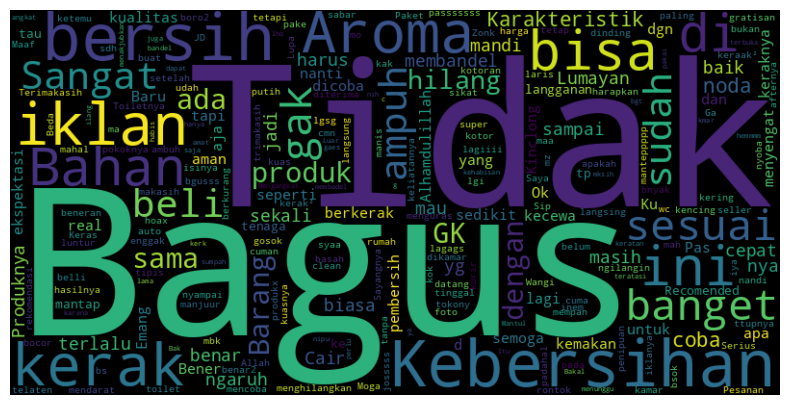

In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Mengisi nilai NaN dengan string kosong ('')
df['review_text'] = df['review_text'].fillna(" ")

# Menggabungkan teks dari kolom 'Review text'
text=' '.join(df['review_text'].astype(str).tolist())

stopwords = set(STOPWORDS)

wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt. axis("off")
plt. show()

### Word Frequent Checking

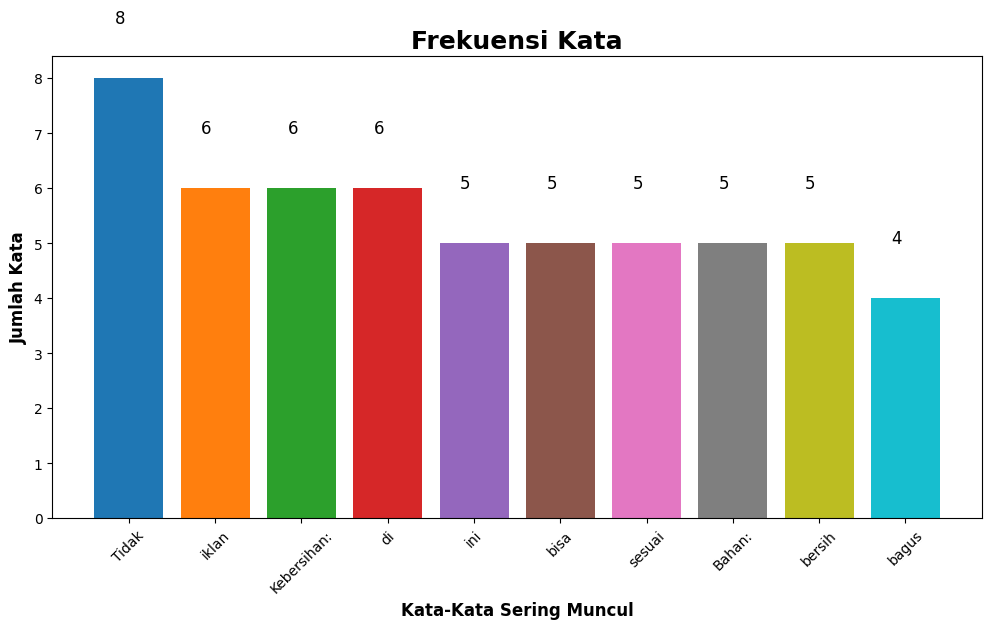

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

text = "".join(df["review_text"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)

word, count = zip(*top_words)

# palet warna
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

plt.show()

### Cleaning

In [ ]:
import re
import string
import nltk

# Fungsi untuk menghapus emoji
! pip install emoji
import emoji

def remove_emoji(text):
    if text is not None and isinstance(text, str):
        return emoji.replace_emoji(text, replace='')
    return text

# Fungsi untuk menghapus simbol
def remove_symbols(text):
    if text is not None and isinstance(text, str):
        text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

# Fungsi untuk menghapus angka
def remove_numbers(text):
    if text is not None and isinstance(text, str):
        text = re.sub(r'\d+', '', text)
    return text

# Fungsi untuk menambahkan spasi setelah koma
def add_space_after_comma(text):
    if text is not None and isinstance(text, str):
        return re.sub(r',(?=\S)', ', ', text)
    return text

df['Cleaning'] = df['review_text'].apply(lambda x: add_space_after_comma(x))
df['Cleaning'] = df['Cleaning'].apply(lambda x: remove_emoji(x))
df['Cleaning'] = df['Cleaning'].apply(lambda x: remove_symbols(x))
df['Cleaning'] = df['Cleaning'].apply(lambda x: remove_numbers(x))

df.head(10)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.9 MB/s eta 0:00:00


,main_review_id,star_level,review_text,reply_text,reply_count,product_name,product_id,sku_id,sku_specification,order_id,user_name,has_imgs,has_video,review_time,Cleaning
0,7668195900732507922,5,Baik,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585122761963112171,N*****p,False,NaN,1785390988240,Baik
1,7668116289533150983,5,Sangat ambuh super . Bisa belli lagi nanti,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585246419134284845,اسحق ريا,False,NaN,1785372453094,Sangat ambuh super Bisa belli lagi nanti
2,7667822033539172103,5,Lumayan bagus bsok mau beli lgi,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585206110453729130,Tuntum Haney,True,NaN,1785303940667,Lumayan bagus bsok mau beli lgi
3,7667807572170344213,5,Bagus banget real langsing dicoba \nIni yg ben...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585186211111929292,nursalsabila,False,NaN,1785300572747,Bagus banget real langsing dicoba \nIni yg ben...
4,7667505160633190152,1,Barang udah nyampai tapi setelah dicoba GK sam...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585226860986795685,Widayati,False,NaN,1785230162837,Barang udah nyampai tapi setelah dicoba GK sam...
5,7667206005541029648,5,"barang diterima dengan baik, kualitas sesuai e...",NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,584986957713016826,pria gelap,True,NaN,1785160511531,barang diterima dengan baik kualitas sesuai ek...
6,7667171829253752583,1,Kebersihan: Tidak ampuh sama sekali. Toiletnya...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,584797961922512339,ت*****غ,False,NaN,1785152553225,Kebersihan Tidak ampuh sama sekali Toiletnya m...
7,7667156820783597333,1,Ga ngaruh apa apa masih kotor,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585094400381847524,fery--1122,False,NaN,1785149058591,Ga ngaruh apa apa masih kotor
8,7667084463293957895,4,Produknya bgusss 👍,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585180965149509524,Hawa97,False,NaN,1785132211530,Produknya bgusss
9,7667052027646658312,5,Paket datang cepat...Baru mau nyoba...semoga r...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585150088555824713,g*****9,False,NaN,1785124660051,Paket datang cepatBaru mau nyobasemoga realbuk...


### Case Folding

In [ ]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['Cleaning'].apply(case_folding)
df

,main_review_id,star_level,review_text,reply_text,reply_count,product_name,product_id,sku_id,sku_specification,order_id,user_name,has_imgs,has_video,review_time,Cleaning,case_folding
0,7668195900732507922,5,Baik,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585122761963112171,N*****p,False,NaN,1785390988240,Baik,baik
1,7668116289533150983,5,Sangat ambuh super . Bisa belli lagi nanti,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585246419134284845,اسحق ريا,False,NaN,1785372453094,Sangat ambuh super Bisa belli lagi nanti,sangat ambuh super bisa belli lagi nanti
2,7667822033539172103,5,Lumayan bagus bsok mau beli lgi,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585206110453729130,Tuntum Haney,True,NaN,1785303940667,Lumayan bagus bsok mau beli lgi,lumayan bagus bsok mau beli lgi
3,7667807572170344213,5,Bagus banget real langsing dicoba \nIni yg ben...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585186211111929292,nursalsabila,False,NaN,1785300572747,Bagus banget real langsing dicoba \nIni yg ben...,bagus banget real langsing dicoba \nini yg ben...
4,7667505160633190152,1,Barang udah nyampai tapi setelah dicoba GK sam...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585226860986795685,Widayati,False,NaN,1785230162837,Barang udah nyampai tapi setelah dicoba GK sam...,barang udah nyampai tapi setelah dicoba gk sam...
5,7667206005541029648,5,"barang diterima dengan baik, kualitas sesuai e...",NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,584986957713016826,pria gelap,True,NaN,1785160511531,barang diterima dengan baik kualitas sesuai ek...,barang diterima dengan baik kualitas sesuai ek...
6,7667171829253752583,1,Kebersihan: Tidak ampuh sama sekali. Toiletnya...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,584797961922512339,ت*****غ,False,NaN,1785152553225,Kebersihan Tidak ampuh sama sekali Toiletnya m...,kebersihan tidak ampuh sama sekali toiletnya m...
7,7667156820783597333,1,Ga ngaruh apa apa masih kotor,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585094400381847524,fery--1122,False,NaN,1785149058591,Ga ngaruh apa apa masih kotor,ga ngaruh apa apa masih kotor
8,7667084463293957895,4,Produknya bgusss 👍,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585180965149509524,Hawa97,False,NaN,1785132211530,Produknya bgusss,produknya bgusss
9,7667052027646658312,5,Paket datang cepat...Baru mau nyoba...semoga r...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585150088555824713,g*****9,False,NaN,1785124660051,Paket datang cepatBaru mau nyobasemoga realbuk...,paket datang cepatbaru mau nyobasemoga realbuk...


### World Normalization

In [ ]:
import pandas as pd

# fungsi penggantian kata tidak baku
def replace_taboo_words (text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash (word))
                # else:
                #   replaced_words.append('<karakter eksplisit"।
                #   kalimat_baku.append(word)
            else:
                replaced_words.append(word)
        # Corrected indentation here
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []
    # Corrected indentation here
    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

In [ ]:
# Membaca kamus kata tidak baku
kamus_data = pd.read_excel("/content/drive/MyDrive/Dataset/kamuskatabaku.xlsx")
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [ ]:
# Menerapkan Fungsi Penggantian Kata Tidak Baku
df['normalisasi'], df['Kata_Baku'], df['Kata_Tidak_Baku'], df['Kata_Tidak_Baku_Hash'] = zip(
    *df['case_folding'].apply(
        lambda x: replace_taboo_words(x, kamus_tidak_baku)
    )
)

# Memilih kolom yang digunakan untuk analisis
df = df[[
    'main_review_id',
    'star_level',
    'review_text',
    'reply_text',
    'reply_count',
    'product_name',
    'product_id',
    'sku_id',
    'sku_specification',
    'order_id',
    'user_name',
    'has_imgs',
    'has_video',
    'review_time',
    'Cleaning',
    'case_folding',
    'normalisasi'
]]

In [ ]:
df

,main_review_id,star_level,review_text,reply_text,reply_count,product_name,product_id,sku_id,sku_specification,order_id,user_name,has_imgs,has_video,review_time,Cleaning,case_folding,normalisasi
0,7668195900732507922,5,Baik,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585122761963112171,N*****p,False,NaN,1785390988240,Baik,baik,baik
1,7668116289533150983,5,Sangat ambuh super . Bisa belli lagi nanti,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585246419134284845,اسحق ريا,False,NaN,1785372453094,Sangat ambuh super Bisa belli lagi nanti,sangat ambuh super bisa belli lagi nanti,sangat ambuh super bisa belli lagi nanti
2,7667822033539172103,5,Lumayan bagus bsok mau beli lgi,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585206110453729130,Tuntum Haney,True,NaN,1785303940667,Lumayan bagus bsok mau beli lgi,lumayan bagus bsok mau beli lgi,lumayan bagus besok mau beli lagi
3,7667807572170344213,5,Bagus banget real langsing dicoba \nIni yg ben...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585186211111929292,nursalsabila,False,NaN,1785300572747,Bagus banget real langsing dicoba \nIni yg ben...,bagus banget real langsing dicoba \nini yg ben...,bagus banget real langsing dicoba ini yang ben...
4,7667505160633190152,1,Barang udah nyampai tapi setelah dicoba GK sam...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585226860986795685,Widayati,False,NaN,1785230162837,Barang udah nyampai tapi setelah dicoba GK sam...,barang udah nyampai tapi setelah dicoba gk sam...,barang sudah nyampai tapi setelah dicoba tidak...
5,7667206005541029648,5,"barang diterima dengan baik, kualitas sesuai e...",NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,584986957713016826,pria gelap,True,NaN,1785160511531,barang diterima dengan baik kualitas sesuai ek...,barang diterima dengan baik kualitas sesuai ek...,barang diterima dengan baik kualitas sesuai ek...
6,7667171829253752583,1,Kebersihan: Tidak ampuh sama sekali. Toiletnya...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,584797961922512339,ت*****غ,False,NaN,1785152553225,Kebersihan Tidak ampuh sama sekali Toiletnya m...,kebersihan tidak ampuh sama sekali toiletnya m...,kebersihan tidak ampuh sama sekali toiletnya m...
7,7667156820783597333,1,Ga ngaruh apa apa masih kotor,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585094400381847524,fery--1122,False,NaN,1785149058591,Ga ngaruh apa apa masih kotor,ga ngaruh apa apa masih kotor,tidak ngaruh apa apa masih kotor
8,7667084463293957895,4,Produknya bgusss 👍,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585180965149509524,Hawa97,False,NaN,1785132211530,Produknya bgusss,produknya bgusss,produknya bgusss
9,7667052027646658312,5,Paket datang cepat...Baru mau nyoba...semoga r...,NaN,0,{EKSKLUSIF INEM JOGJA} Klinbos Pembersih Toile...,1732196765442344656,1732255787324901072,1 PCS + FREE KUAS,585150088555824713,g*****9,False,NaN,1785124660051,Paket datang cepatBaru mau nyobasemoga realbuk...,paket datang cepatbaru mau nyobasemoga realbuk...,paket datang cepatbaru mau nyobasemoga realbuk...


# Text Preprocessing

## Tokenization

In [ ]:
# Fungsi Tokenisasi
def tokenize(text):
    tokens = text.split()
    return tokens

# Menerapkan tokenisasi pada kolom normalisasi
df['tokenize'] = df['normalisasi'].apply(lambda x: tokenize(x))

# Memilih kolom yang diperlukan dan mengganti nama kolom normalisasi
df_cleaned = df[
    ['review_time', 'user_name', 'star_level', 'normalisasi', 'tokenize']
].rename(
    columns={'normalisasi': 'reviewText_cleaned'}
)

# Menampilkan 5 data teratas
df_cleaned.head()

,review_time,user_name,star_level,reviewText_cleaned,tokenize
0,1785390988240,N*****p,5,baik,[baik]
1,1785372453094,اسحق ريا,5,sangat ambuh super bisa belli lagi nanti,"[sangat, ambuh, super, bisa, belli, lagi, nanti]"
2,1785303940667,Tuntum Haney,5,lumayan bagus besok mau beli lagi,"[lumayan, bagus, besok, mau, beli, lagi]"
3,1785300572747,nursalsabila,5,bagus banget real langsing dicoba ini yang ben...,"[bagus, banget, real, langsing, dicoba, ini, y..."
4,1785230162837,Widayati,1,barang sudah nyampai tapi setelah dicoba tidak...,"[barang, sudah, nyampai, tapi, setelah, dicoba..."


## Proses Stopword Removal

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def remove_stopwords(text) :
  return [word for word in text if word not in stop_words]

df_cleaned['stopword removal'] = df_cleaned['tokenize'].apply(lambda x: remove_stopwords(x))
df_cleaned

,review_time,user_name,star_level,reviewText_cleaned,tokenize,stopword removal
0,1785390988240,N*****p,5,baik,[baik],[]
1,1785372453094,اسحق ريا,5,sangat ambuh super bisa belli lagi nanti,"[sangat, ambuh, super, bisa, belli, lagi, nanti]","[ambuh, super, belli]"
2,1785303940667,Tuntum Haney,5,lumayan bagus besok mau beli lagi,"[lumayan, bagus, besok, mau, beli, lagi]","[lumayan, bagus, besok, beli]"
3,1785300572747,nursalsabila,5,bagus banget real langsing dicoba ini yang ben...,"[bagus, banget, real, langsing, dicoba, ini, y...","[bagus, banget, real, langsing, dicoba, benara..."
4,1785230162837,Widayati,1,barang sudah nyampai tapi setelah dicoba tidak...,"[barang, sudah, nyampai, tapi, setelah, dicoba...","[barang, nyampai, dicoba, iklan, keraknya, hil..."
5,1785160511531,pria gelap,5,barang diterima dengan baik kualitas sesuai ek...,"[barang, diterima, dengan, baik, kualitas, ses...","[barang, diterima, kualitas, sesuai, ekspektasi]"
6,1785152553225,ت*****غ,1,kebersihan tidak ampuh sama sekali toiletnya m...,"[kebersihan, tidak, ampuh, sama, sekali, toile...","[kebersihan, ampuh, toiletnya]"
7,1785149058591,fery--1122,1,tidak ngaruh apa apa masih kotor,"[tidak, ngaruh, apa, apa, masih, kotor]","[ngaruh, kotor]"
8,1785132211530,Hawa97,4,produknya bgusss,"[produknya, bgusss]","[produknya, bgusss]"
9,1785124660051,g*****9,5,paket datang cepatbaru mau nyobasemoga realbuk...,"[paket, datang, cepatbaru, mau, nyobasemoga, r...","[paket, cepatbaru, nyobasemoga, realbukan, hoax]"


## Proses Steaming Data

In [ ]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return [stemmer.stem(word) for word in text]

df_cleaned['steming_data'] = df_cleaned['stopword removal'].apply(lambda x: ' '.join(stem_text(x))).replace('', np.nan)
df_cleaned.head(5)

,review_time,user_name,star_level,reviewText_cleaned,tokenize,stopword removal,steming_data
0,1785390988240,N*****p,5,baik,[baik],[],NaN
1,1785372453094,اسحق ريا,5,sangat ambuh super bisa belli lagi nanti,"[sangat, ambuh, super, bisa, belli, lagi, nanti]","[ambuh, super, belli]",ambuh super belli
2,1785303940667,Tuntum Haney,5,lumayan bagus besok mau beli lagi,"[lumayan, bagus, besok, mau, beli, lagi]","[lumayan, bagus, besok, beli]",lumayan bagus besok beli
3,1785300572747,nursalsabila,5,bagus banget real langsing dicoba ini yang ben...,"[bagus, banget, real, langsing, dicoba, ini, y...","[bagus, banget, real, langsing, dicoba, benara...",bagus banget real langsing coba benar bersih a...
4,1785230162837,Widayati,1,barang sudah nyampai tapi setelah dicoba tidak...,"[barang, sudah, nyampai, tapi, setelah, dicoba...","[barang, nyampai, dicoba, iklan, keraknya, hil...",barang nyampai coba iklan kerak hilang


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_time         50 non-null     int64 
 1   user_name           50 non-null     object
 2   star_level          50 non-null     int64 
 3   reviewText_cleaned  50 non-null     object
 4   tokenize            50 non-null     object
 5   stopword removal    50 non-null     object
 6   steming_data        49 non-null     object
dtypes: int64(2), object(5)
memory usage: 2.9+ KB


In [ ]:
data = df_cleaned.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49 entries, 1 to 49
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_time         49 non-null     int64 
 1   user_name           49 non-null     object
 2   star_level          49 non-null     int64 
 3   reviewText_cleaned  49 non-null     object
 4   tokenize            49 non-null     object
 5   stopword removal    49 non-null     object
 6   steming_data        49 non-null     object
dtypes: int64(2), object(5)
memory usage: 3.1+ KB


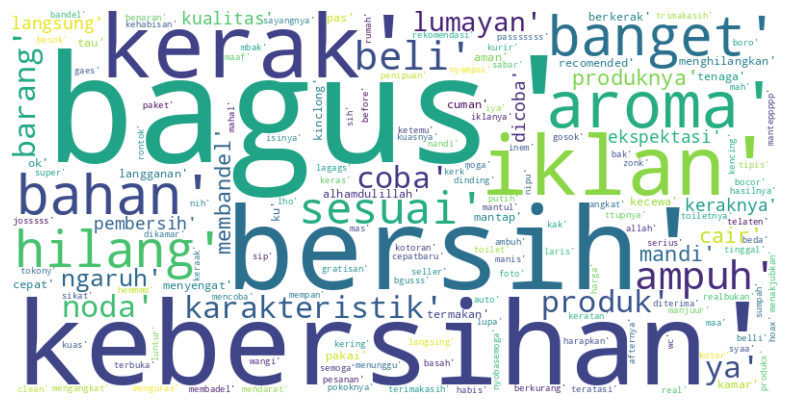

In [ ]:
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Menggabungkan teks dari kolom 'steming_data'
text = ' '.join(df_cleaned['stopword removal'].astype(str).tolist())

stopwords = set(STOPWORDS)

wc = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

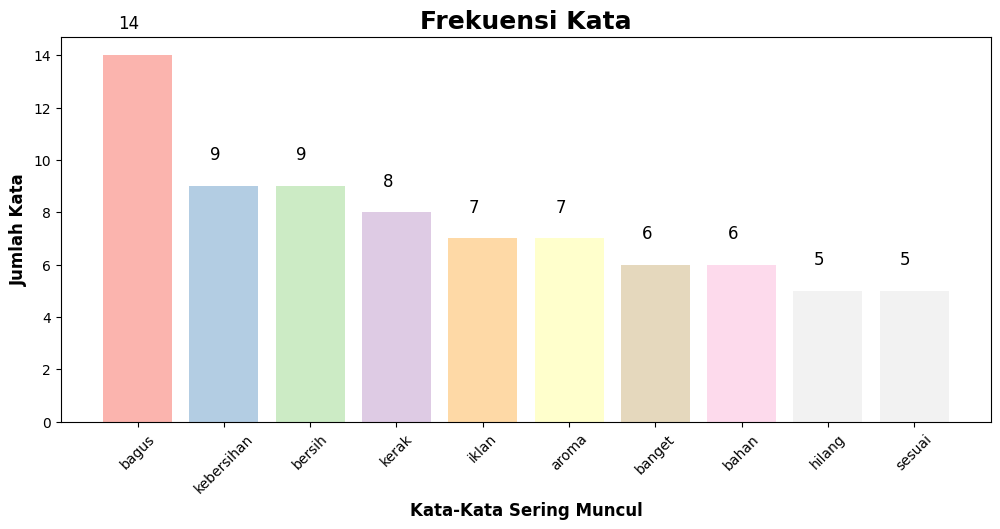

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# Convert the list of words in 'stopword removal' to strings before joining
text = ' '.join([' '.join(words) for words in df_cleaned["stopword removal"]])

stopwords = set(STOPWORDS)

tokens = [word for word in text.split() if word not in stopwords]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)
# Menggunakan palet warna lebih lembut
colors = plt.cm.Pastel1(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()

# Labeling

## Pelabelan Data

In [ ]:
data = pd.DataFrame(df_cleaned[['star_level', 'steming_data']])
data

,star_level,steming_data
0,5,NaN
1,5,ambuh super belli
2,5,lumayan bagus besok beli
3,5,bagus banget real langsing coba benar bersih a...
4,1,barang nyampai coba iklan kerak hilang
5,5,barang terima kualitas sesuai ekspektasi
6,1,bersih ampuh toilet
7,1,ngaruh kotor
8,4,produk bgusss
9,5,paket cepatbaru nyobasemoga realbukan hoax


In [ ]:
data['Sentiment'] = data['star_level'].apply(
    lambda x: 'positive' if x >= 4 else 'negative'
)

data

,star_level,steming_data,Sentiment
0,5,NaN,positive
1,5,ambuh super belli,positive
2,5,lumayan bagus besok beli,positive
3,5,bagus banget real langsing coba benar bersih a...,positive
4,1,barang nyampai coba iklan kerak hilang,negative
5,5,barang terima kualitas sesuai ekspektasi,positive
6,1,bersih ampuh toilet,negative
7,1,ngaruh kotor,negative
8,4,produk bgusss,positive
9,5,paket cepatbaru nyobasemoga realbukan hoax,positive


## Wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# memsisahkan dataset berdasarkan sentimen
sentimen_negative = data[data['Sentiment'] == 'negative']['steming_data'].str.cat(sep=' ')
sentimen_positive = data[data['Sentiment'] == 'positive']['steming_data'].str.cat(sep=' ')

## Wordcloud sentimen negative

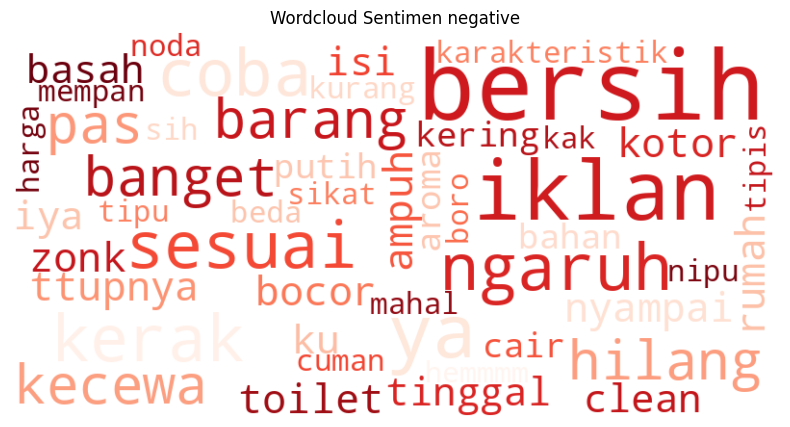

In [ ]:
# Membuat dan menampilkan wordcloud

def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, colormap='Reds',background_color='white').generate(text)
    return wordcloud

# membuat wordcloud untuk sentimen negatif
wordcloud_negative = create_wordcloud(sentimen_negative, 'Wordcloud Sentimen negative')

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Sentimen negative')
plt.show()

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Memisahkan setiap teks menjadi kata-kata
words_negative = sentimen_negative.split()

# Menghitung frekuensi setiap kata
word_freq_negative = Counter(words_negative)

# Mengubah hasil menjadi DataFrame
df_word_freq_negative = pd.DataFrame(
    word_freq_negative.items(),
    columns=['Kata', 'Frekuensi']
).sort_values(
    by='Frekuensi',
    ascending=False
)

# Menampilkan 20 kata yang paling sering muncul
df_word_freq_negative.head(20)

,Kata,Frekuensi
6,bersih,7
3,iklan,5
19,ya,4
4,kerak,3
9,ngaruh,3
11,sesuai,3
2,coba,3
13,kecewa,2
5,hilang,2
21,pas,2


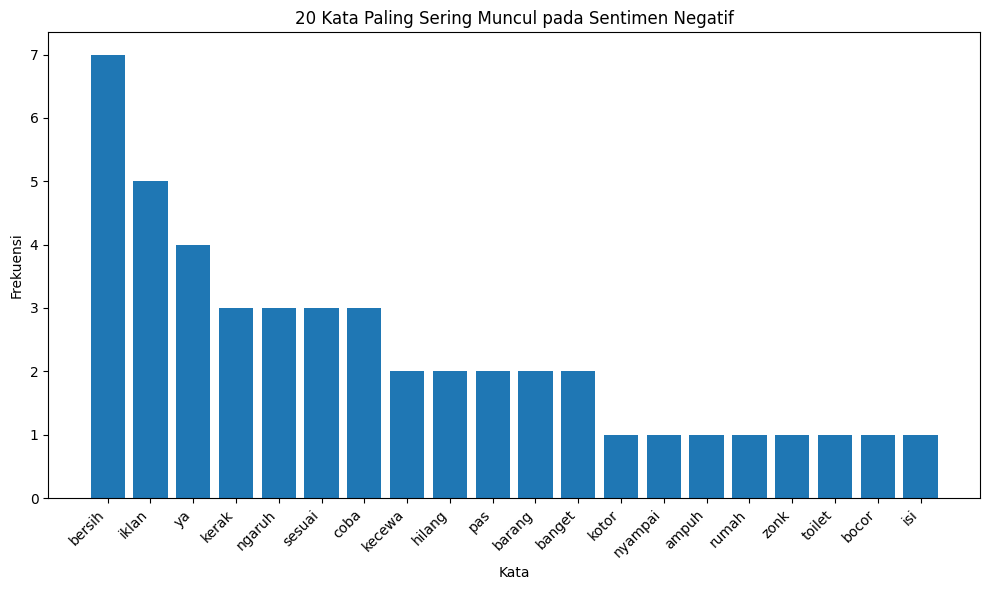

In [ ]:
# Mengambil 20 kata dengan frekuensi tertinggi
top_words_negative = df_word_freq_negative.head(20)

# Membuat grafik
plt.figure(figsize=(10, 6))
plt.bar(
    top_words_negative['Kata'],
    top_words_negative['Frekuensi']
)

plt.title('20 Kata Paling Sering Muncul pada Sentimen Negatif')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Wordcloud sentimen positive

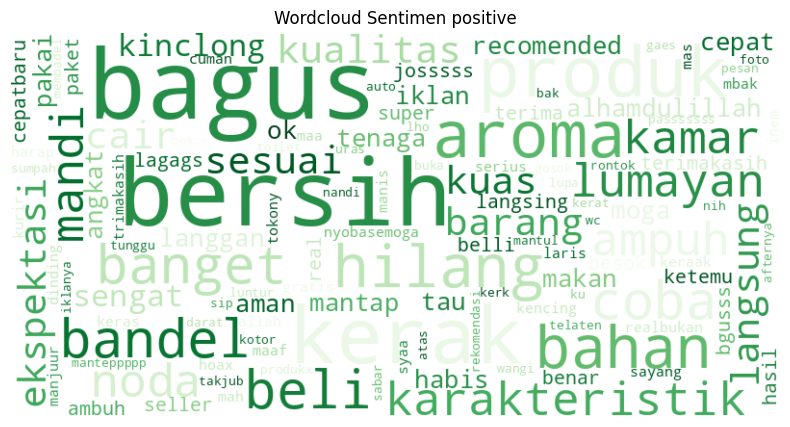

In [ ]:
# Membuat dan menampilkan wordcloud

def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, colormap='Greens',background_color='white').generate(text)
    return wordcloud

# membuat wordcloud untuk sentimen negatif
wordcloud_positive=create_wordcloud(sentimen_positive, 'Wordcloud Sentimen positive')

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Sentimen positive')
plt.show()

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# Menggabungkan seluruh teks sentimen positif
all_words_positive = sentimen_positive

# Menghitung frekuensi setiap kata
word_freq_positive = Counter(all_words_positive.split())

# Membuat DataFrame frekuensi kata
df_word_freq_positive = pd.DataFrame(
    word_freq_positive.items(),
    columns=['Kata', 'Frekuensi']
).sort_values(
    by='Frekuensi',
    ascending=False
)

# Menampilkan 20 kata yang paling sering muncul
df_word_freq_positive.head(20)

,Kata,Frekuensi
4,bagus,14
12,bersih,13
54,kerak,9
14,produk,7
32,aroma,6
33,bahan,5
42,hilang,5
7,banget,4
10,coba,4
6,beli,4


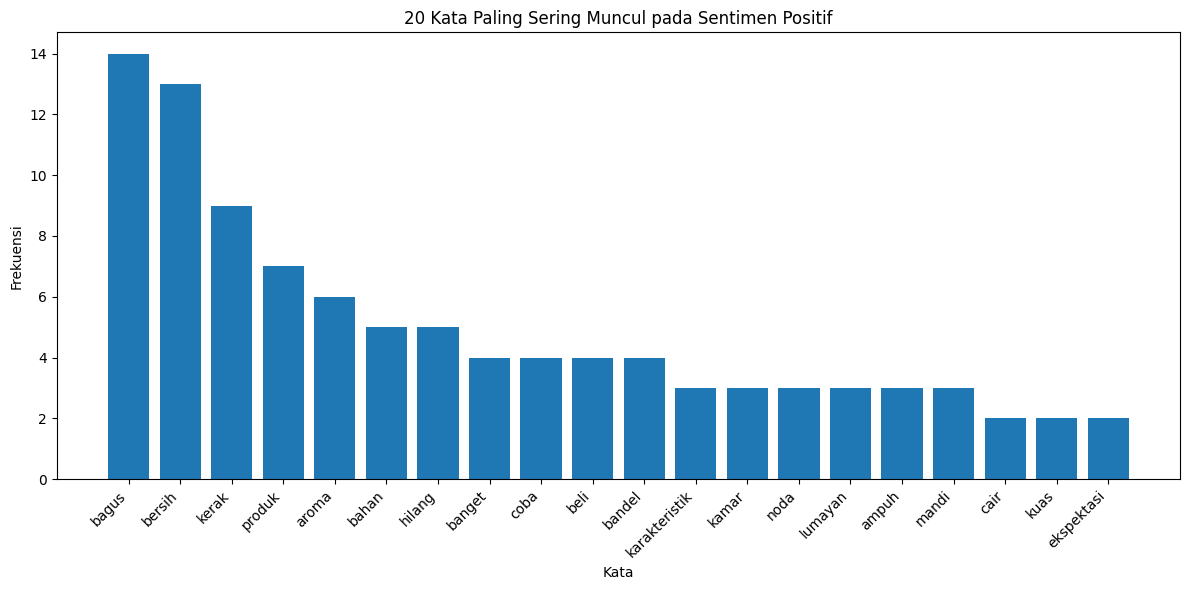

In [ ]:
# Mengambil 20 kata dengan frekuensi tertinggi
top_words_positive = df_word_freq_positive.head(20)

# Membuat grafik frekuensi kata
plt.figure(figsize=(12, 6))

plt.bar(
    top_words_positive['Kata'],
    top_words_positive['Frekuensi']
)

plt.title('20 Kata Paling Sering Muncul pada Sentimen Positif')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Distribusi Sentimen

In [ ]:
import plotly.express as px

# Hitung jumlah masing-masing label sentimen
sentiment_counts = data['Sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# Barplot dengan Plotly
fig = px.bar(
    sentiment_counts,
    x='Sentiment',
    y='Count',
    text='Count',
    title='Distribusi Sentimen Positif dengan Sentimen Negatif',
    color='Sentiment',
    color_discrete_sequence=["#1dd1a1", "#ff6b6b", "#54a0ff"]
)

# Tambahkan label di atas bar
fig.update_traces(textposition='outside')
fig.update_layout(
    xaxis_title='Sentimen',
    yaxis_title='Jumlah',
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

fig.show()
